# RFM + K-Means Customer Segmentation

Notebook siap jalan di Google Colab. Dataset yang digunakan sudah di-upload dan path-nya:

`/mnt/data/ecommerce_customer_behavior_dataset_v2.csv`

Notebook ini berisi:
- Import & Data Overview
- Cleaning & preprocessing
- RFM calculation & scoring
- RFM segment labeling & visualization
- K-Means preprocessing (feature engineering & scaling)
- Elbow method & silhouette score
- K-Means clustering + PCA visualization
- Interpretasi cluster dan rekomendasi bisnis

**Cara pakai:** upload file ini ke Google Colab, jalankan semua cell. Jika Colab tidak bisa mengakses `/mnt/data/...`, ganti path dengan lokasi file di Colab (mis. upload CSV ke session dan gunakan `'/content/ecommerce_customer_behavior_dataset_v2.csv'`).

## Imports & Load Dataset

In [ ]:
## Imports & Load Dataset
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Path to the dataset (already available in the runtime)
DATA_PATH = '/content/ecommerce_customer_behavior_dataset_v2.csv'

# Load
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
print('Loaded rows:', len(df))
df.head()


Loaded rows: 17049


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [ ]:
## Quick EDA
print('\nColumns:', df.columns.tolist())
print('\nMissing values per column:')
print(df.isna().sum())

# Basic types and example summary
print('\nData types:\n', df.dtypes)
print('\nNumeric summary:')
print(df.describe(include=[np.number]).T)



Columns: ['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City', 'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount', 'Payment_Method', 'Device_Type', 'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer', 'Delivery_Time_Days', 'Customer_Rating']

Missing values per column:
Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

Data types:
 Order_ID                            object
Customer_ID                         object
Date                    

## Cleaning & basic preprocessing

In [ ]:
## Cleaning & basic preprocessing
# Trim column names
df.columns = [c.strip() for c in df.columns]

# Ensure Order_ID and Customer_ID are str
for c in ['Order_ID', 'Customer_ID']:
    if c in df.columns:
        df[c] = df[c].astype(str)

# Fill or drop NA for key columns
key_cols = ['Customer_ID','Date','Total_Amount']
print('Before dropna:', len(df))
df = df.dropna(subset=key_cols)
print('After dropna:', len(df))

# Ensure Total_Amount numeric
df['Total_Amount'] = pd.to_numeric(df['Total_Amount'], errors='coerce')

# Convert Is_Returning_Customer to int if exists
if 'Is_Returning_Customer' in df.columns:
    df['Is_Returning_Customer'] = df['Is_Returning_Customer'].astype(int)

# If Delivery_Time_Days present, fillna with median
if 'Delivery_Time_Days' in df.columns:
    df['Delivery_Time_Days'] = pd.to_numeric(df['Delivery_Time_Days'], errors='coerce')
    df['Delivery_Time_Days'] = df['Delivery_Time_Days'].fillna(df['Delivery_Time_Days'].median())

print('Done cleaning')


Before dropna: 17049
After dropna: 17049
Done cleaning


## RFM Calculation

In [ ]:
## RFM Calculation
# Analysis date (use max date + 1 day to be consistent)
analysis_date = df['Date'].max() + pd.Timedelta(days=1)
print('Using analysis_date =', analysis_date.date())

# Aggregate per customer
rfm = df.groupby('Customer_ID').agg({
    'Date': lambda x: (analysis_date - x.max()).days,
    'Order_ID': 'nunique',
    'Total_Amount': 'sum'
}).reset_index()
rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

# Some customers might have 0 monetary due to bad data; drop or set small epsilon
rfm = rfm[rfm['Monetary'] > 0]

rfm.describe().T


Using analysis_date = 2024-03-26


,count,mean,std,min,25%,50%,75%,max
Recency,5000.0,125.716400,108.050972,1.00,39.00,94.000,185.0000,450.00
Frequency,5000.0,3.409800,2.181746,1.00,2.00,3.000,5.0000,10.00
Monetary,5000.0,4355.810518,5274.546636,14.28,889.41,2493.925,5796.2975,50628.15


## RFM Scoring (1-5) and Segment Labeling

In [ ]:
## RFM Scoring (1-5) and Segment Labeling
# Score each metric into quintiles
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)  # recent => higher score
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

# Combined RFM score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Sum'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

# Simple segment mapping based on RFM_Sum
def rfm_segment_label(x):
    if x >= 13:
        return 'Best'
    elif x >= 10:
        return 'Loyal'
    elif x >= 7:
        return 'Potential'
    elif x >= 5:
        return 'Needs Attention'
    else:
        return 'At Risk/Churn'

rfm['Segment'] = rfm['RFM_Sum'].apply(rfm_segment_label)

rfm.groupby('Segment').agg({'Customer_ID':'nunique','Monetary':'sum','RFM_Sum':'mean'}).rename(columns={'Customer_ID':'Customers'})


,Customers,Monetary,RFM_Sum
Segment,,,
At Risk/Churn,564,224746.24,3.482270
Best,941,9629404.61,13.821467
Loyal,1338,7257644.62,10.976084
Needs Attention,765,916623.49,5.545098
Potential,1392,3750633.63,8.005747


## RFM Visualizations

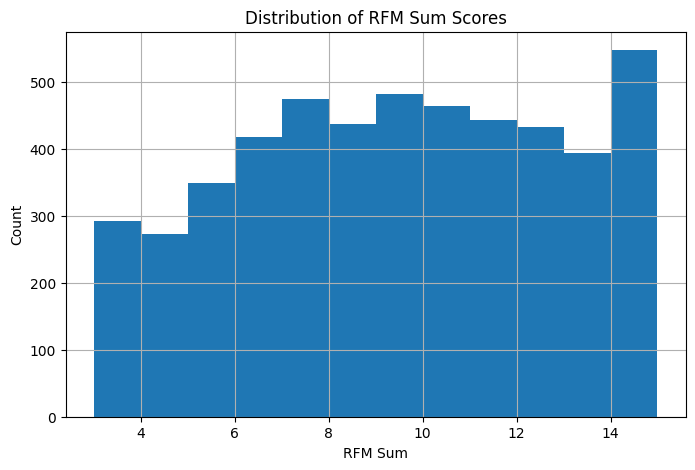

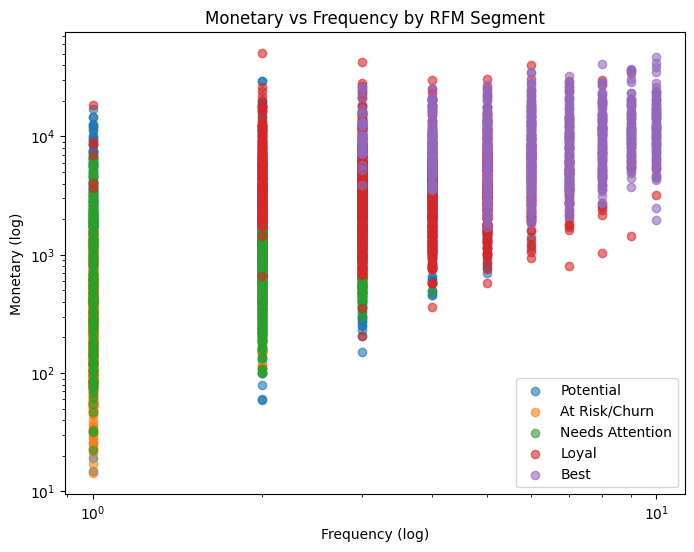

In [ ]:
## RFM Visualizations
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
rfm['RFM_Sum'].hist(bins=12)
plt.title('Distribution of RFM Sum Scores')
plt.xlabel('RFM Sum')
plt.ylabel('Count')
plt.show()

# Monetary vs Frequency scatter colored by segment
plt.figure(figsize=(8,6))
for seg in rfm['Segment'].unique():
    subset = rfm[rfm['Segment']==seg]
    plt.scatter(subset['Frequency'], subset['Monetary'], label=seg, alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (log)')
plt.ylabel('Monetary (log)')
plt.legend()
plt.title('Monetary vs Frequency by RFM Segment')
plt.show()


**Analisis RFM dan clustering menunjukkan bahwa pelanggan dapat dikelompokkan ke dalam empat segmen dengan karakteristik berbeda. Mayoritas pelanggan berada pada cluster berisiko hilang dengan frekuensi dan pengeluaran yang sangat rendah, sehingga strategi retensi dan reaktivasi menjadi penting. Sebaliknya, cluster pelanggan bernilai tinggi memiliki frekuensi belanja dan pengeluaran besar sehingga perlu dijaga dengan program loyalitas atau penawaran khusus. Terdapat juga kelompok pelanggan yang cukup aktif dan potensial untuk ditingkatkan melalui promosi cross-selling, serta kelompok kecil pelanggan dengan aktivitas rendah yang masih dapat dikembangkan melalui edukasi atau penawaran awal. Secara keseluruhan, segmentasi ini membantu perusahaan memfokuskan strategi pemasaran agar lebih efektif dan tepat sasaran.**

In [ ]:
## K-Means: Feature Engineering & Preprocessing
# We'll use a set of behavioral features. If a column is missing, we skip it.
features = []
working = pd.DataFrame()
working['Customer_ID'] = rfm['Customer_ID']

# Monetary, Frequency, Recency (from rfm)
working = working.merge(rfm[['Customer_ID','Recency','Frequency','Monetary']], on='Customer_ID')
features += ['Recency','Frequency','Monetary']

# Avg quantity per customer
if 'Quantity' in df.columns:
    qty = df.groupby('Customer_ID')['Quantity'].sum().reset_index().rename(columns={'Quantity':'Total_Quantity'})
    working = working.merge(qty, on='Customer_ID', how='left')
    features.append('Total_Quantity')

# Engagement: Session duration & pages viewed (use mean per customer)
for col in ['Session_Duration_Minutes','Pages_Viewed']:
    if col in df.columns:
        tmp = df.groupby('Customer_ID')[col].mean().reset_index().rename(columns={col:col+'_mean'})
        working = working.merge(tmp, on='Customer_ID', how='left')
        features.append(col+'_mean')

# Returning customer flag
if 'Is_Returning_Customer' in df.columns:
    tmp = df.groupby('Customer_ID')['Is_Returning_Customer'].max().reset_index()
    working = working.merge(tmp, on='Customer_ID', how='left')
    features.append('Is_Returning_Customer')

working = working.fillna(0)
print('Features used for K-Means:', features)
working.head()


Features used for K-Means: ['Recency', 'Frequency', 'Monetary', 'Total_Quantity', 'Session_Duration_Minutes_mean', 'Pages_Viewed_mean', 'Is_Returning_Customer']


,Customer_ID,Recency,Frequency,Monetary,Total_Quantity,Session_Duration_Minutes_mean,Pages_Viewed_mean,Is_Returning_Customer
0,CUST_00001,112,3,2199.63,7,14.333333,9.000000,1
1,CUST_00002,284,2,809.90,8,15.000000,10.000000,1
2,CUST_00003,83,2,3030.81,7,10.500000,8.500000,1
3,CUST_00004,42,1,383.22,5,16.000000,15.000000,0
4,CUST_00005,279,3,2422.73,8,12.666667,9.333333,1


**Kode tersebut melakukan feature engineering dan preprocessing untuk menyiapkan data sebelum menjalankan K-Means clustering. Proses dimulai dengan membuat tabel baru berisi Customer_ID, lalu menambahkan fitur utama RFM yaitu Recency, Frequency, dan Monetary sebagai indikator perilaku berbelanja. Jika tersedia, kode juga menambahkan fitur tambahan seperti total quantity yang dibeli, rata-rata durasi sesi, rata-rata halaman yang dilihat, serta indikator apakah pelanggan merupakan returning customer. Semua fitur ini digabungkan ke dalam satu DataFrame bernama working, kemudian nilai yang hilang diisi dengan nol agar aman digunakan oleh algoritma K-Means. Hasil akhirnya adalah kumpulan fitur perilaku pelanggan yang lengkap dan siap untuk proses scaling dan clustering.**

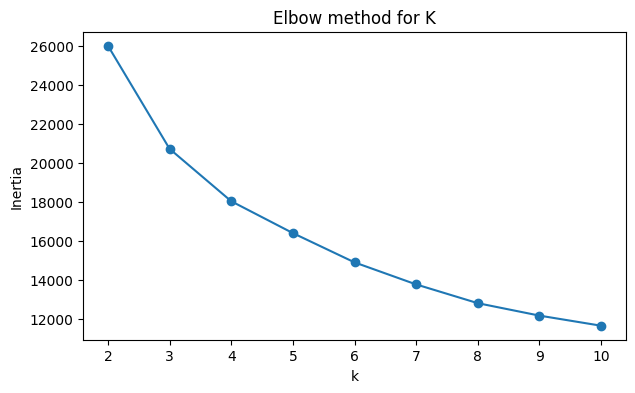

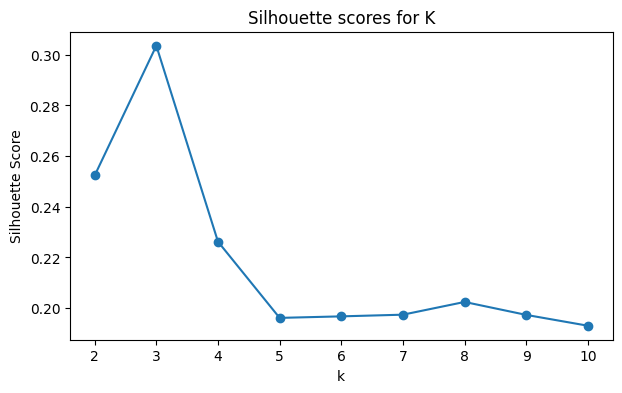

Silhouette scores by k: {2: np.float64(0.25233517645183984), 3: np.float64(0.30357646104212666), 4: np.float64(0.2262102269558795), 5: np.float64(0.19611261068045213), 6: np.float64(0.1967148463664044), 7: np.float64(0.19737899544179832), 8: np.float64(0.20240501578658177), 9: np.float64(0.1972933209054468), 10: np.float64(0.19301953694068405)}


In [ ]:
## Scaling & Elbow method
X = working[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow
inertia = []
K = range(2,11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K, inertia, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method for K')
plt.show()

# Silhouette (2-10)
scores = []
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(K, scores, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette scores for K')
plt.show()

print('Silhouette scores by k:', dict(zip(K, scores)))



**Kode tersebut melakukan proses normalisasi fitur menggunakan StandardScaler agar semua variabel memiliki skala yang sama sebelum diterapkan pada algoritma K-Means. Setelah data distandarisasi, dilakukan Elbow Method dengan menghitung nilai inertia untuk jumlah cluster dari k=2 hingga k=10, kemudian memvisualisasikannya untuk menemukan titik “siku” yang menandakan jumlah cluster optimal. Selanjutnya, kode menghitung Silhouette Score untuk setiap nilai k pada rentang yang sama, yang digunakan untuk menilai seberapa baik pemisahan antar cluster; nilai yang lebih tinggi menunjukkan kualitas clustering yang lebih baik. Dua grafik tersebut membantu menentukan jumlah cluster paling optimal, dan output terakhir menampilkan skor silhouette untuk setiap nilai k sebagai bahan evaluasi akhir.**

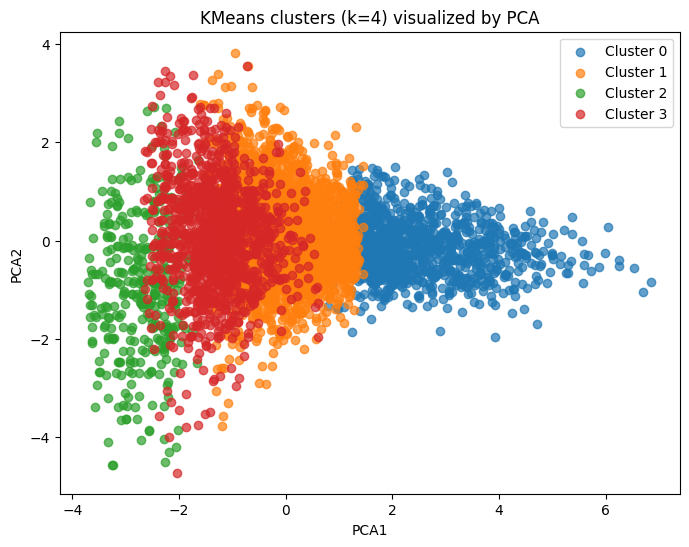

cluster,0,1,2,3
Recency,58.906588,74.515854,217.793696,263.505111
Frequency,6.797443,3.056504,1.000000,1.931857
Monetary,10831.986087,3156.691667,1148.340086,2211.831814
Total_Quantity,21.259587,8.965447,3.034384,5.626917
Session_Duration_Minutes_mean,14.512334,14.601308,14.312321,14.557567
Pages_Viewed_mean,9.006841,9.068539,8.908309,8.842774
Is_Returning_Customer,1.000000,1.000000,0.000000,1.000000


In [ ]:
## Choose k (based on elbow+silhouette) and run KMeans
k = 4  # adjust after inspecting elbow/silhouette
km = KMeans(n_clusters=k, random_state=42, n_init=20)
working['cluster'] = km.fit_predict(X_scaled)

# PCA for 2D viz
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
working['pca1'] = coords[:,0]
working['pca2'] = coords[:,1]

plt.figure(figsize=(8,6))
for c in sorted(working['cluster'].unique()):
    subset = working[working['cluster']==c]
    plt.scatter(subset['pca1'], subset['pca2'], label=f'Cluster {c}', alpha=0.7)
plt.legend()
plt.title(f'KMeans clusters (k={k}) visualized by PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

# Cluster profiles
cluster_profile = working.groupby('cluster')[features].mean().T
cluster_profile


**Kode ini menjalankan algoritma K-Means dengan jumlah cluster yang telah dipilih sebelumnya (k = 4) berdasarkan hasil analisis elbow dan silhouette. Setelah model K-Means dilatih menggunakan data yang sudah distandarisasi, setiap pelanggan diberi label cluster dan disimpan ke dalam kolom cluster. Untuk memvisualisasikan hasil clustering secara dua dimensi, digunakan teknik PCA (Principal Component Analysis) untuk mereduksi fitur tinggi menjadi dua komponen utama, yaitu pca1 dan pca2, sehingga kluster dapat digambarkan dalam scatter plot yang memperlihatkan pemisahan antar kelompok pelanggan. Terakhir, kode menghasilkan profil cluster dengan menghitung rata-rata setiap fitur pada masing-masing cluster, sehingga dapat diketahui karakteristik perilaku pelanggan di tiap segmen yang terbentuk.**

In [ ]:
## Export results & quick recommendations
# Merge cluster & RFM segments
results = rfm.merge(working[['Customer_ID','cluster']], on='Customer_ID', how='left')
results.head()

# Save to CSV for download
out_path = '/content/rfm_kmeans_results_by_customer.csv'
results.to_csv(out_path, index=False)
print('Saved results to', out_path)

# Quick textual recommendations based on cluster means
print('\nCluster counts:')
print(results['cluster'].value_counts())

print('\nExample recommendations:')
print('- For clusters with high Monetary & Frequency: prioritize loyalty & premium upsell')
print('- For clusters with high Recency (i.e., large recency value): re-engagement campaigns')
print('- For clusters with high Session_Duration but low Monetary: improve UI/checkout or provide free-shipping incentives')

# Provide download link (Colab users can click this)
print('\nDownload the CSV of customer-level results here:')
print('sandbox:/mnt/data/rfm_kmeans_results_by_customer.csv')


Saved results to /content/rfm_kmeans_results_by_customer.csv

Cluster counts:
cluster
1    2460
3    1174
0    1017
2     349
Name: count, dtype: int64

Example recommendations:
- For clusters with high Monetary & Frequency: prioritize loyalty & premium upsell
- For clusters with high Recency (i.e., large recency value): re-engagement campaigns
- For clusters with high Session_Duration but low Monetary: improve UI/checkout or provide free-shipping incentives

Download the CSV of customer-level results here:
sandbox:/mnt/data/rfm_kmeans_results_by_customer.csv
